In [1]:
# ============================================================
# EEMS → Skeleton → SLA → Posterior ∩ SLA → Validation
# Full pipeline with paths + buffer scale factor
# ============================================================

import re
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, LineString
from shapely.ops import unary_union
from shapely.prepared import prep

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.tri as mtri

from skimage.morphology import skeletonize
from scipy.spatial import cKDTree
import jenkspy
from tqdm import tqdm

# -----------------------------
# 0. USER CONFIG
# -----------------------------
# Root directory where all EEMS chains live
BASE_DIR = Path(
    "C:/Users/yli129/Documents/eems_process/sim_data/all_flat_sim5"
)

# Base name of this run (without _chain# suffix)
#RUN_NAME = "sim5_N15_rep009"

# Which chains to include
CHAIN_IDS = [1, 2, 3, 4, 5, 6]

# Coordinates & EEMS plotting
LONG_LAT = True        # (lon, lat)
NMRKS    = 250        # grid "dpi" for EEMS
PROB_LEVEL = 0.9      # posterior prob threshold



# Toggle overlays (to match R's add_grid / add_demes / add_outline)
ADD_GRID    = True
ADD_DEMES   = True
ADD_OUTLINE = False



# Skeleton / SLA
# Skeleton / SLA
# We will build SLAs for three scales: 0.5, 1.0, 2.0
SLA_SCALE_FACTORS = [0.5, 1.0, 2.0]

# KDE
KDE_CELL_FACTOR = 250    # ArcGIS-like: min(width,height)/factor

# Ground-truth for validation
SIM_DATA_ROOT = Path(
    "C:/Users/yli129/Documents/eems_process/ground_truth"
)
SIM_NAME   = "sim5_a"   # subfolder
SIM_PREFIX = "sim5"     # file prefix
BARRIER_RATE = 0.001
EDGE_FRAC_THRESHOLD = 0.3   # fraction of edge length in region => predicted barrier

# --------------------------------------------------
# 1. PATHS DERIVED FROM CONFIG (only edit above)
# --------------------------------------------------
CHAIN_DIRS = [BASE_DIR / f"{RUN_NAME}_chain{i}" for i in CHAIN_IDS]

OUT_GEOJSON_DIR = BASE_DIR / "eems_geojson" / RUN_NAME
OUT_GEOJSON_DIR.mkdir(parents=True, exist_ok=True)

POPCOORDS_FILE = SIM_DATA_ROOT / SIM_NAME / f"{SIM_PREFIX}.popcoords"
EDGERATES_FILE = SIM_DATA_ROOT / SIM_NAME / f"{SIM_PREFIX}.edgerates"

print("EEMS base dir:     ", BASE_DIR)
print("Run name:          ", RUN_NAME)
print("Chain dirs:        ", [p.name for p in CHAIN_DIRS])
print("GeoJSON out dir:   ", OUT_GEOJSON_DIR)
print("Popcoords file:    ", POPCOORDS_FILE)
print("Edgerates file:    ", EDGERATES_FILE)

# =====================================================
# 2. EEMS HELPERS (read outputs, build surfaces)
# =====================================================

def read_vector(path: Path) -> np.ndarray:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return np.fromfile(path, sep=" ")


def read_matrix(path: Path, ncol: int) -> np.ndarray:
    vals = read_vector(path)
    if vals.size % ncol != 0:
        raise ValueError(f"{path} cannot be reshaped into {ncol} columns")
    return vals.reshape((-1, ncol))


def get_dist_metric(mcmcpath: Path) -> str:
    f = mcmcpath / "eemsrun.txt"
    dist_metric = "euclidean"
    if f.exists():
        with f.open() as fh:
            for line in fh:
                line_l = line.strip().lower()
                m = re.search(r"distance\s*=\s*(\w+)", line_l)
                if m:
                    dist_metric = m.group(1)
                    break
    if dist_metric not in ("euclidean", "greatcirc"):
        raise ValueError(f"Unknown distance metric in eemsrun.txt: {dist_metric}")
    return dist_metric


def default_eems_colors():
    hex_colors = [
        "#994000", "#CC5800", "#FF8F33", "#FFAD66", "#FFCA99", "#FFE6CC",
        "#FBFBFB",
        "#CCFDFF", "#99F8FF", "#66F0FF", "#33E4FF", "#00AACC", "#007A99"
    ]
    return ListedColormap(hex_colors)


def read_dimns(mcmcpath: Path, longlat: bool = True, nmrks: int = 250):
    outer = read_matrix(mcmcpath / "outer.txt", ncol=2)
    ipmap = read_vector(mcmcpath / "ipmap.txt").astype(int)
    demes_xy = read_matrix(mcmcpath / "demes.txt", ncol=2)
    edges_idx = read_matrix(mcmcpath / "edges.txt", ncol=2).astype(int)

    dist_metric = get_dist_metric(mcmcpath)

    if not longlat:
        outer = outer[:, [1, 0]]
        demes_xy = demes_xy[:, [1, 0]]

    xlim = (outer[:, 0].min(), outer[:, 0].max())
    ylim = (outer[:, 1].min(), outer[:, 1].max())

    # aspect for plotting (same as R)
    aspect = ((ylim[1] - ylim[0]) / (xlim[1] - xlim[0])) / np.cos(
        np.deg2rad(np.mean(ylim))
    )
    aspect = abs(aspect)

    # grid dims (only used for plotting; marks are subset)
    if aspect > 1:
        nx = nmrks
        ny = int(round(nx * aspect))
    else:
        ny = nmrks
        nx = int(round(ny / aspect))

    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)
    marks_all = np.column_stack([X.ravel(), Y.ravel()])

    from matplotlib.path import Path as MplPath
    poly_path = MplPath(outer)
    inside = poly_path.contains_points(marks_all)
    marks = marks_all[inside]

    # deme sample sizes via ipmap (1-based IDs)
    n_demes = demes_xy.shape[0]
    sizes = np.zeros(n_demes, dtype=int)
    if ipmap.size > 0:
        uniq, counts = np.unique(ipmap, return_counts=True)
        uniq0 = uniq - 1
        uniq0 = uniq0[(uniq0 >= 0) & (uniq0 < n_demes)]
        sizes[uniq0] = counts[:len(uniq0)]

    demes = np.column_stack([demes_xy, sizes])

    e0 = edges_idx[:, 0] - 1
    e1 = edges_idx[:, 1] - 1
    edges = np.column_stack(
        [
            demes_xy[e0, 0],
            demes_xy[e0, 1],
            demes_xy[e1, 0],
            demes_xy[e1, 1],
        ]
    )

    return {
        "marks": marks,
        "xlim": xlim,
        "ylim": ylim,
        "outer": outer,
        "demes": demes,  # x, y, n
        "edges": edges,  # x, y, xend, yend
        "dist_metric": dist_metric,
    }


def read_voronoi_raw(mcmcpath: Path, longlat: bool, is_mrates: bool):
    if is_mrates:
        rates = read_vector(mcmcpath / "mcmcmrates.txt")
        tiles = read_vector(mcmcpath / "mcmcmtiles.txt").astype(int)
        xseed = read_vector(mcmcpath / "mcmcxcoord.txt")
        yseed = read_vector(mcmcpath / "mcmcycoord.txt")
    else:
        rates = read_vector(mcmcpath / "mcmcqrates.txt")
        tiles = read_vector(mcmcpath / "mcmcqtiles.txt").astype(int)
        xseed = read_vector(mcmcpath / "mcmcwcoord.txt")
        yseed = read_vector(mcmcpath / "mcmczcoord.txt")

    if not longlat:
        xseed, yseed = yseed, xseed

    seeds = np.column_stack([xseed, yseed])
    rates = np.log10(rates)

    return {"rates": rates, "tiles": tiles, "seeds": seeds}


def pairwise_sqdist_euclidean(A, B):
    diff = A[:, None, :] - B[None, :, :]
    return np.sum(diff * diff, axis=2)


def pairwise_sqdist_greatcircle(A, B):
    lon1 = np.deg2rad(A[:, 0])[:, None]
    lat1 = np.deg2rad(A[:, 1])[:, None]
    lon2 = np.deg2rad(B[:, 0])[None, :]
    lat2 = np.deg2rad(B[:, 1])[None, :]

    dlon = lon1 - lon2
    dlat = lat1 - lat2

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return c * c


from scipy.spatial import cKDTree
from tqdm import tqdm
from scipy.spatial import cKDTree

def tiles2contours_python(
    marks,
    tiles,
    rates,
    seeds,
    distm,
    desc="m",              # kept for compatibility but no tqdm here
    thin=1,
    use_kdtree=True,
    kdtree_min_seeds=50,
):
    """
    Faster version of tiles2contours (no progress bar inside):

    - optional iteration thinning: process only every `thin`-th iteration
    - for Euclidean distance, uses cKDTree instead of full distance matrix
      when number of seeds >= kdtree_min_seeds.

    Parameters
    ----------
    marks : (Nmarks, 2) float
    tiles : (Niters,) int
        tiles[t] = number of Voronoi seeds in iteration t.
    rates : (sum(tiles),) float (log10 transformed by read_voronoi_raw).
    seeds : (sum(tiles), 2) float
    distm : "euclidean" or "greatcirc"
    desc : str
        (unused now; kept only for backward compatibility)
    thin : int
        Use every `thin`th iteration. 1 = use all (original behavior).
    use_kdtree : bool
        If True and distm == "euclidean", use cKDTree for nearest neighbor.
    kdtree_min_seeds : int
        Only switch to KDTree if this iteration has at least this many seeds.

    Returns
    -------
    z_sum   : (Nmarks,) float  – sum of centered log10(rate) across used iters
    pr_gt0  : (Nmarks,) float  – counts of (z > 0) across used iters
    pr_lt0  : (Nmarks,) float  – counts of (z < 0) across used iters
    niters_used : int          – number of iterations actually used (after thinning)
    """
    tiles = np.asarray(tiles, dtype=int)
    nmrks = marks.shape[0]

    z_sum = np.zeros(nmrks, dtype=float)
    pr_gt0 = np.zeros(nmrks, dtype=float)
    pr_lt0 = np.zeros(nmrks, dtype=float)

    pos = 0
    niters_used = 0

    for iter_idx, now_tiles in enumerate(tiles):
        now_tiles = int(now_tiles)
        if now_tiles <= 0:
            continue

        # Extract this iteration's seeds/rates
        now_rates = rates[pos:pos + now_tiles]
        now_seeds = seeds[pos:pos + now_tiles, :]
        pos += now_tiles

        # Thinning: skip iterations not divisible by `thin`
        if thin > 1 and (iter_idx % thin != 0):
            continue

        # Find nearest seed for each mark
        if (distm == "euclidean") and use_kdtree and (now_tiles >= kdtree_min_seeds):
            # KDTree approach (much faster than full NxM matrix for large Nmarks)
            tree = cKDTree(now_seeds)
            _, nearest = tree.query(marks, k=1)
            z = now_rates[nearest]
        else:
            # Fallback: full distance matrix
            if distm == "greatcirc":
                d2 = pairwise_sqdist_greatcircle(marks, now_seeds)
            else:
                d2 = pairwise_sqdist_euclidean(marks, now_seeds)
            nearest = np.argmin(d2, axis=1)
            z = now_rates[nearest]

        # Center by mean (as in C++ / R code)
        z = z - z.mean()

        # Accumulate
        z_sum += z
        pr_gt0 += (z > 0).astype(float)
        pr_lt0 += (z < 0).astype(float)
        niters_used += 1

    return z_sum, pr_gt0, pr_lt0, niters_used



def compute_eems_surface_multi(
    chain_paths,
    longlat=True,
    nmrks=250,
    is_mrates=True,
    thin=1,
    use_kdtree=True,
    kdtree_min_seeds=50,
):
    """
    Multi-chain EEMS surface with optional:
      - iteration thinning
      - KDTree-based nearest-neighbor

    Parameters
    ----------
    chain_paths : list of Path
    longlat    : bool
    nmrks      : int
    is_mrates  : bool
    thin       : int
        Thin MCMC iterations (1 = use all).
    use_kdtree : bool
        Use KDTree in Euclidean case.
    kdtree_min_seeds : int
        Minimum number of seeds in an iteration to switch to KDTree.

    Returns
    -------
    dimns : dict
    z_mean : (nmarks,)
    pr_gt0 : (nmarks,)
    pr_lt0 : (nmarks,)
    """
    chain_paths = [Path(p) for p in chain_paths]
    if not chain_paths:
        raise ValueError("chain_paths must be non-empty")

    # Geometry from first chain
    dimns = read_dimns(chain_paths[0], longlat=longlat, nmrks=nmrks)
    marks = dimns["marks"]
    distm = dimns["dist_metric"]
    nmarks = marks.shape[0]

    z_total = np.zeros(nmarks, dtype=float)
    pr_gt0_tot = np.zeros(nmarks, dtype=float)
    pr_lt0_tot = np.zeros(nmarks, dtype=float)
    niters_tot = 0

    label = "m" if is_mrates else "q"

    for p in tqdm(chain_paths, desc=f"EEMS chains ({label})"):
        vor = read_voronoi_raw(p, longlat=longlat, is_mrates=is_mrates)
        zvals, pr_gt0, pr_lt0, niters_used = tiles2contours_python(
            marks,
            vor["tiles"],
            vor["rates"],
            vor["seeds"],
            distm,
            desc=label,
            thin=thin,
            use_kdtree=use_kdtree,
            kdtree_min_seeds=kdtree_min_seeds,
        )
        z_total += zvals
        pr_gt0_tot += pr_gt0
        pr_lt0_tot += pr_lt0
        niters_tot += niters_used

    if niters_tot == 0:
        raise RuntimeError("No iterations used in tiles2contours (check thin parameter).")

    z_mean = z_total / niters_tot
    pr_gt0 = pr_gt0_tot / niters_tot
    pr_lt0 = pr_lt0_tot / niters_tot

    return dimns, z_mean, pr_gt0, pr_lt0

# === Step 1: build positive (blue) and negative (orange) migration regions ===
import numpy as np
import matplotlib.tri as mtri
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union

def build_pos_neg_polygons(dimns, z_mean, threshold=0.0):
    """
    Merge all positive EEMS migration (z_mean > threshold) into one region,
    and all negative (z_mean < threshold) into another.
    
    Returns
    -------
    pos_region : shapely geometry or None
        MultiPolygon (or Polygon) representing all positive (blue) areas.
    neg_region : shapely geometry or None
        MultiPolygon (or Polygon) representing all negative (orange) areas.
    """
    marks = dimns["marks"]
    x = marks[:, 0]
    y = marks[:, 1]
    z = np.asarray(z_mean, dtype=float)

    tri = mtri.Triangulation(x, y)
    triangles = tri.triangles  # (n_triangles, 3) indices into marks

    pos_polys = []
    neg_polys = []

    for a, b, c in triangles:
        idx = np.array([a, b, c])
        z_tri = z[idx]
        if np.any(np.isnan(z_tri)):
            continue

        z_avg = z_tri.mean()
        coords = np.column_stack([x[idx], y[idx]])
        poly = Polygon(coords)

        if not poly.is_valid or poly.area == 0.0:
            continue

        if z_avg > threshold:
            pos_polys.append(poly)
        elif z_avg < threshold:
            neg_polys.append(poly)
        # if z_avg == 0, ignore (boundary)

    pos_region = unary_union(pos_polys) if pos_polys else None
    neg_region = unary_union(neg_polys) if neg_polys else None

    return pos_region, neg_region


from shapely.geometry import Point, LineString, MultiLineString
from shapely.ops import unary_union
from shapely.prepared import prep
from skimage.morphology import skeletonize

def polygon_to_skeleton_lines(geom, nx=400):
    """
    Compute a topological skeleton for a (Multi)Polygon in WGS84.

    Parameters
    ----------
    geom : shapely Polygon or MultiPolygon
        Positive or negative migration region.
    nx : int
        Number of raster columns (resolution in x). ny is chosen based on aspect.

    Returns
    -------
    skeleton_lines : shapely.MultiLineString or LineString or None
        Skeleton as vector lines in the same CRS as the polygon (WGS84).
    """
    if geom is None or geom.is_empty:
        return None

    # Merge pieces (if MultiPolygon) and get bounds
    geom = unary_union(geom)
    minx, miny, maxx, maxy = geom.bounds
    if maxx <= minx or maxy <= miny:
        return None

    # Build a regular grid over the bounding box
    xs = np.linspace(minx, maxx, nx)
    aspect = (maxy - miny) / (maxx - minx)
    ny = max(2, int(round(nx * aspect)))
    ys = np.linspace(miny, maxy, ny)

    XX, YY = np.meshgrid(xs, ys)  # XX(j,i) = x, YY(j,i) = y
    coords = np.column_stack([XX.ravel(), YY.ravel()])

    # Rasterize: mark grid cells whose centers are inside the polygon
    prepared = prep(geom)
    mask_flat = np.array(
        [prepared.contains(Point(x, y)) for x, y in coords],
        dtype=bool
    )
    mask = mask_flat.reshape((ny, nx))

    if not mask.any():
        return None

    # Skeletonize the binary mask
    skel = skeletonize(mask)

    # Convert skeleton pixels to line segments in lon/lat
    segs = []
    # 8-connected neighbors to get a more complete centerline network
    neighbor_offsets = [
        (0, 1), (1, 0), (0, -1), (-1, 0),
        (1, 1), (1, -1), (-1, 1), (-1, -1),
    ]

    skel_y, skel_x = np.nonzero(skel)  # row (y index), col (x index)
    skel_pixels = set(zip(skel_y, skel_x))

    for (i, j) in skel_pixels:
        x1 = xs[j]
        y1 = ys[i]
        for di, dj in neighbor_offsets:
            ni, nj = i + di, j + dj
            if (ni, nj) in skel_pixels:
                x2 = xs[nj]
                y2 = ys[ni]
                segs.append(LineString([(x1, y1), (x2, y2)]))

    if not segs:
        return None

    skeleton_lines = unary_union(segs)
    return skeleton_lines


def select_skeletons_by_distance(
    skel_geom,
    sample_points,
    use_median=True,
    thresh=None,
):
    """
    For each LineString in skel_geom, compute distance to the nearest
    sample point. Then either:
      - use_median=True: threshold = median(D_sk)
      - or provide a custom 'thresh' (same units as coordinates).

    Returns
    -------
    distances : list[float]
        D_sk for each segment (same order as segments).
    d_med : float
        Median (if use_median) or threshold used.
    selected_geom : MultiLineString or LineString or None
        Skeleton segments with D_sk <= d_med.
    removed_geom : MultiLineString or LineString or None
        Skeleton segments with D_sk > d_med.
    """
    segs = split_skeleton_geom(skel_geom)
    if not segs or not sample_points:
        return [], None, None, None

    d_list = []
    for ln in segs:
        d_min = min(ln.distance(pt) for pt in sample_points)
        d_list.append(d_min)

    d_arr = np.array(d_list)
    if thresh is None:
        if use_median:
            d_med = float(np.median(d_arr))
        else:
            raise ValueError("If use_median=False you must provide 'thresh'.")
    else:
        d_med = float(thresh)

    selected = [ln for ln, d in zip(segs, d_list) if d <= d_med]
    removed  = [ln for ln, d in zip(segs, d_list) if d > d_med]

    sel_geom = unary_union(selected) if selected else None
    rem_geom = unary_union(removed)  if removed  else None

    return d_list, d_med, sel_geom, rem_geom



def read_logposterior_chain(mcmcpath: Path):
    mat = read_matrix(mcmcpath / "mcmcpilogl.txt", ncol=2)
    pi = mat[:, 0]
    logl = mat[:, 1]
    return pi + logl


def plot_eems_rate_map(
    dimns,
    zmean,
    is_mrates=True,
    add_grid=False,
    add_demes=False,
    add_outline=False,
    m_colscale=(-2.5, 2.5),
    q_colscale=(-0.1, 0.1),
):
    cmap = default_eems_colors()
    x = dimns["marks"][:, 0]
    y = dimns["marks"][:, 1]

    if is_mrates:
        vmin, vmax = m_colscale
        bar_label = "log(m)"
    else:
        vmin, vmax = q_colscale
        bar_label = "log(q)"

    n_bins = cmap.N
    levels = np.linspace(vmin, vmax, n_bins + 1)
    norm = BoundaryNorm(levels, ncolors=n_bins)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_facecolor("white")

    tri = mtri.Triangulation(x, y)
    cf = ax.tricontourf(tri, zmean, levels=levels, cmap=cmap, norm=norm, extend="both")

    if add_grid and "edges" in dimns:
        for x1, y1, x2, y2 in dimns["edges"]:
            ax.plot([x1, x2], [y1, y2], color="#BBBBBB", linewidth=0.5, zorder=2)

    if add_demes and "demes" in dimns:
        demes = dimns["demes"]
        mask = demes[:, 2] > 0
        if np.any(mask):
            d = demes[mask]
            sizes = np.clip(d[:, 2], 1, None) * 10.0
            ax.scatter(
                d[:, 0],
                d[:, 1],
                s=sizes,
                color="red",
                edgecolors="red",
                linewidths=0.8,
                zorder=3,
            )

    if add_outline and "outer" in dimns:
        outer = dimns["outer"]
        ax.plot(outer[:, 0], outer[:, 1], color="#FFFFFF", linewidth=1.0, zorder=3)

    ax.set_xlim(dimns["xlim"])
    ax.set_ylim(dimns["ylim"])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

    cbar = fig.colorbar(cf, ax=ax, boundaries=levels)
    cbar.set_label(bar_label)
    if is_mrates:
        cbar.set_ticks([-2, -1, 0, 1, 2])
    else:
        cbar.set_ticks([-0.1, -0.05, 0.0, 0.05, 0.1])

    fig.tight_layout()
    return fig, ax


def plot_eems_prob_map(
    dimns,
    pr_gt0,
    pr_lt0,
    is_mrates=True,
    prob_low=0.9,
    prob_high=0.95,
    add_grid=False,
    add_demes=False,
    add_outline=False,
):
    x = dimns["marks"][:, 0]
    y = dimns["marks"][:, 1]

    cats = np.zeros_like(pr_gt0, dtype=float)

    neg_hi = pr_lt0 >= prob_high
    neg_lo = (pr_lt0 >= prob_low) & (pr_lt0 < prob_high)
    pos_lo = (pr_gt0 >= prob_low) & (pr_gt0 < prob_high)
    pos_hi = pr_gt0 >= prob_high

    cats[neg_hi] = -2
    cats[neg_lo] = -1
    cats[pos_lo] = 1
    cats[pos_hi] = 2

    base = default_eems_colors()
    neg_hi_color = base(0)
    neg_lo_color = base(2)
    pos_lo_color = base(10)
    pos_hi_color = base(12)

    prob_cmap = ListedColormap(
        [neg_hi_color, neg_lo_color, "white", pos_lo_color, pos_hi_color]
    )

    levels = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
    norm = BoundaryNorm(levels, ncolors=prob_cmap.N)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_facecolor("white")

    tri = mtri.Triangulation(x, y)
    cf = ax.tricontourf(
        tri,
        cats,
        levels=levels,
        cmap=prob_cmap,
        norm=norm,
        extend="neither",
    )

    if add_grid and "edges" in dimns:
        for x1, y1, x2, y2 in dimns["edges"]:
            ax.plot([x1, x2], [y1, y2], color="#BBBBBB", linewidth=0.5, zorder=2)

    if add_demes and "demes" in dimns:
        demes = dimns["demes"]
        mask_d = demes[:, 2] > 0
        if np.any(mask_d):
            d = demes[mask_d]
            sizes = np.clip(d[:, 2], 1, None) * 10.0
            ax.scatter(
                d[:, 0],
                d[:, 1],
                s=sizes,
                color="red",
                edgecolors="red",
                linewidths=0.8,
                zorder=3,
            )

    if add_outline and "outer" in dimns:
        outer = dimns["outer"]
        ax.plot(outer[:, 0], outer[:, 1], color="#FFFFFF", linewidth=1.0, zorder=3)

    ax.set_xlim(dimns["xlim"])
    ax.set_ylim(dimns["ylim"])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

    cbar = fig.colorbar(cf, ax=ax, boundaries=levels)
    r = "m" if is_mrates else "q"
    cbar.set_ticks([-2, -1, 1, 2])
    cbar.set_ticklabels(
        [
            f"{prob_high}  (P(log({r})<0))",
            f"{prob_low}   (P(log({r})<0))",
            f"{prob_low}   (P(log({r})>0))",
            f"{prob_high}  (P(log({r})>0))",
        ]
    )
    cbar.ax.set_ylabel("posterior probability")

    fig.tight_layout()
    return fig, ax


def plot_log_posterior_multi(chain_paths):
    fig, ax = plt.subplots(figsize=(7, 5))
    for i, p in enumerate(chain_paths, start=1):
        pilogl = read_logposterior_chain(Path(p))
        iters = np.arange(1, pilogl.size + 1)
        ax.plot(iters, pilogl, label=f"chain {i}")
    ax.set_xlabel("MCMC iteration")
    ax.set_ylabel("log posterior")
    ax.set_title("MCMC log posterior (all chains)")
    ax.legend(title="Chain", loc="upper right")
    ax.grid(False)
    fig.tight_layout()
    return fig, ax

# =====================================================
# 3. HELPER: infer grid shape from 1D vector
# =====================================================

def infer_grid_shape_from_vector(vec, xlim, ylim, min_ny=10):
    N = len(vec)
    width = xlim[1] - xlim[0]
    height = ylim[1] - ylim[0]
    if width <= 0 or height <= 0:
        raise ValueError("Invalid xlim/ylim for grid shape inference.")
    target_ratio = height / width

    best_ny = None
    best_nx = None
    best_err = float("inf")

    for ny in range(min_ny, int(np.sqrt(N)) + 1):
        if N % ny != 0:
            continue
        nx = N // ny
        ratio = ny / nx
        err = abs(ratio - target_ratio)
        if err < best_err:
            best_err = err
            best_ny = ny
            best_nx = nx

    if best_ny is None or best_nx is None:
        raise ValueError(f"Could not infer grid shape for N={N}.")

    print(
        f"Inferred grid shape: ny={best_ny}, nx={best_nx}, "
        f"ratio={best_ny / best_nx:.3f}, target_ratio={target_ratio:.3f}, "
        f"error={best_err:.3e}"
    )
    return best_ny, best_nx

# =====================================================
# 4. REGIONS + SKELETONS
# =====================================================

def build_signed_region_masks_and_polygons(dimns, z_vec, thresh=0.0):
    xlim = dimns["xlim"]
    ylim = dimns["ylim"]
    N = len(z_vec)

    ny, nx = infer_grid_shape_from_vector(z_vec, xlim, ylim)
    z_grid = z_vec.reshape((ny, nx))

    pos_mask = z_grid > thresh
    neg_mask = z_grid < -thresh  # or < 0

    xmin, xmax = xlim
    ymin, ymax = ylim
    cell_w = (xmax - xmin) / nx
    cell_h = (ymax - ymin) / ny

    def mask_to_union(mask):
        polys = []
        for j in range(ny):
            for i in range(nx):
                if not mask[j, i]:
                    continue
                x0 = xmin + i * cell_w
                x1 = x0 + cell_w
                y0 = ymin + j * cell_h
                y1 = y0 + cell_h
                polys.append(
                    Polygon([(x0, y0), (x1, y0), (x1, y1), (x0, y1)])
                )
        if not polys:
            return None
        return unary_union(polys)

    pos_region = mask_to_union(pos_mask)
    neg_region = mask_to_union(neg_mask)

    return {
        "ny": ny,
        "nx": nx,
        "cell_w": cell_w,
        "cell_h": cell_h,
        "z_grid": z_grid,
        "pos_mask": pos_mask,
        "neg_mask": neg_mask,
        "pos_region": pos_region,
        "neg_region": neg_region,
    }


def skeleton_mask_to_lines(mask, xlim, ylim, crs=None):
    ny, nx = mask.shape
    xmin, xmax = xlim
    ymin, ymax = ylim
    cell_w = (xmax - xmin) / nx
    cell_h = (ymax - ymin) / ny

    lines = []
    for j in range(ny):
        for i in range(nx):
            if not mask[j, i]:
                continue
            x0 = xmin + (i + 0.5) * cell_w
            y0 = ymin + (j + 0.5) * cell_h

            if i + 1 < nx and mask[j, i + 1]:
                x1 = xmin + (i + 1 + 0.5) * cell_w
                y1 = y0
                lines.append(LineString([(x0, y0), (x1, y1)]))

            if j + 1 < ny and mask[j + 1, i]:
                x1 = x0
                y1 = ymin + (j + 1 + 0.5) * cell_h
                lines.append(LineString([(x0, y0), (x1, y1)]))

    gdf = gpd.GeoDataFrame(
        {"seg_id": np.arange(len(lines))},
        geometry=lines,
        crs=crs,
    )
    print(f"Skeleton line segments created: {len(gdf)}")
    return gdf


def compute_Dmed_from_skeletons(skel_gdf, sample_xy, points_per_segment=10):
    tree = cKDTree(sample_xy)
    all_dists = []
    per_seg_min = []

    for geom in tqdm(skel_gdf.geometry, desc="D_med from skeletons", leave=False):
        if geom.is_empty or geom.length == 0:
            per_seg_min.append(np.inf)
            continue

        n_pts = max(2, points_per_segment)
        distances = np.linspace(0.0, geom.length, n_pts)
        pts = [
            geom.interpolate(d) for d in distances
        ]
        coords = np.array([[p.x, p.y] for p in pts])
        dists, _ = tree.query(coords, k=1)
        per_seg_min.append(dists.min())
        all_dists.extend(dists.tolist())

    all_dists = np.asarray(all_dists, dtype=float)
    D_med = float(np.median(all_dists))
    print(f"Global D_med (skeleton→nearest sample): {D_med}")
    return D_med, np.asarray(per_seg_min, dtype=float)

# ---------------------------------------------
# B. Sample locations from dimns_m
# ---------------------------------------------
def get_sample_points(dimns):
    """Return list of shapely Points: demes with n > 0."""
    demes = np.asarray(dimns["demes"], dtype=float)   # cols: x, y, n
    mask = demes[:, 2] > 0
    pts = [Point(x, y) for x, y in demes[mask, :2]]
    return pts


# ---------------------------------------------
# C. Split skeleton geom into segments
# ---------------------------------------------
def split_skeleton_geom(skel_geom):
    if skel_geom is None:
        return []
    if isinstance(skel_geom, LineString):
        return [skel_geom]
    if isinstance(skel_geom, MultiLineString):
        return list(skel_geom.geoms)
    # fallback
    return [skel_geom]

# =====================================================
# 5. KDE + Jenks + segmentation + SLA buffers
# =====================================================

def weighted_median(values, weights=None):
    values = np.asarray(values, dtype=float)
    if weights is None:
        return np.median(values)
    w = np.asarray(weights, dtype=float)
    sorter = np.argsort(values)
    v_sorted = values[sorter]
    w_sorted = w[sorter]
    cumsum = np.cumsum(w_sorted)
    cutoff = 0.5 * cumsum[-1]
    return v_sorted[np.searchsorted(cumsum, cutoff)]


def arcgis_default_bandwidth_xy(coords, weights=None):
    coords = np.asarray(coords, dtype=float)
    x = coords[:, 0]
    y = coords[:, 1]

    if weights is None:
        w = np.ones(len(coords), dtype=float)
    else:
        w = np.asarray(weights, dtype=float)

    wsum = w.sum()

    xw = np.average(x, weights=w)
    yw = np.average(y, weights=w)

    dx = x - xw
    dy = y - yw
    dist_center = np.sqrt(dx * dx + dy * dy)

    Dm = weighted_median(dist_center, w)
    SD = np.sqrt(np.sum(w * (dx * dx + dy * dy)) / wsum)
    n = wsum

    h = 0.9 * min(SD, 1.4826 * Dm) * (n ** (-1.0 / 6.0))
    return float(h), float(Dm), float(SD)


def kernel_density_quartic(
    sample_xy,
    weights=None,
    xlim=None,
    ylim=None,
    cell_factor=250,
    bandwidth=None,
):
    sample_xy = np.asarray(sample_xy, dtype=float)
    x = sample_xy[:, 0]
    y = sample_xy[:, 1]

    if weights is None:
        w = np.ones(len(sample_xy), dtype=float)
    else:
        w = np.asarray(weights, dtype=float)

    if xlim is None:
        xpad = 0.02 * (x.max() - x.min())
        xlim = [x.min() - xpad, x.max() + xpad]
    if ylim is None:
        ypad = 0.02 * (y.max() - y.min())
        ylim = [y.min() - ypad, y.max() + ypad]

    xmin, xmax = xlim
    ymin, ymax = ylim
    width = xmax - xmin
    height = ymax - ymin

    cell_size = min(width, height) / float(cell_factor)
    nx = int(np.ceil(width / cell_size))
    ny = int(np.ceil(height / cell_size))

    xs = np.linspace(xmin + cell_size / 2, xmax - cell_size / 2, nx)
    ys = np.linspace(ymin + cell_size / 2, ymax - cell_size / 2, ny)
    XX, YY = np.meshgrid(xs, ys)

    if bandwidth is None:
        h, Dm, SD = arcgis_default_bandwidth_xy(sample_xy, weights=w)
    else:
        h = float(bandwidth)
        _, Dm, SD = arcgis_default_bandwidth_xy(sample_xy, weights=w)

    print(f"# sampled points: {len(sample_xy)}")
    print(f"Kernel density bandwidth h (deg): {h}")
    print(f"Median distance from mean center Dm (deg): {Dm}")
    print(f"Standard distance SD (deg): {SD}")
    print(f"Output cell size (deg): {cell_size}")

    grid_points = np.column_stack([XX.ravel(), YY.ravel()])
    gx = grid_points[:, 0][None, :]
    gy = grid_points[:, 1][None, :]
    sx = x[:, None]
    sy = y[:, None]

    dx = gx - sx
    dy = gy - sy
    dist = np.sqrt(dx * dx + dy * dy)

    u = dist / h
    mask = u < 1.0
    K = np.zeros_like(dist)
    const = 3.0 / (np.pi * h * h)
    K[mask] = const * (1.0 - u[mask] ** 2) ** 2

    density_flat = (K * w[:, None]).sum(axis=0)
    density = density_flat.reshape(XX.shape)

    return {
        "density": density,
        "XX": XX,
        "YY": YY,
        "xlim": xlim,
        "ylim": ylim,
        "cell_size": cell_size,
        "bandwidth": h,
    }


import numpy as np
import jenkspy

def classify_jenks_4(density_grid):
    """
    Classify a density grid into 4 classes using Jenks natural breaks.
    Returns:
      kd_class : same shape as density_grid, values in {1,2,3,4}
      breaks   : list of break points [min, b1, b2, b3, max]
    """
    d = np.asarray(density_grid, dtype=float)
    valid = d[np.isfinite(d)]
    # Only use positive values for Jenks (like before)
    valid_pos = valid[valid > 0]

    if valid_pos.size < 4:
        raise ValueError("Not enough positive density values for Jenks classification.")

    # IMPORTANT: pass number of classes POSITIONALLY, not as keyword
    # This matches your jenkspy version's signature: jenks_breaks(data, n_classes)
    breaks = jenkspy.jenks_breaks(valid_pos, 4)
    # breaks is like [min, b1, b2, b3, max]

    # Digitize into 4 classes (1..4)
    classes = np.digitize(d, breaks[1:-1], right=True) + 1

    print("Jenks breaks:", breaks)
    return classes, breaks



def segment_skeletons_by_kde_class(
    skel_gdf,
    kd_class,
    kde_res,
    min_points_per_segment=3,
    samples_per_cell=4,
    min_class_keep=1,
):
    density = kde_res["density"]
    xlim = kde_res["xlim"]
    ylim = kde_res["ylim"]
    ny, nx = density.shape
    xmin, xmax = xlim
    ymin, ymax = ylim
    cell_w = (xmax - xmin) / nx
    cell_h = (ymax - ymin) / ny

    seg_geoms = []
    seg_class = []
    parent_id = []

    for pid, geom in enumerate(
        tqdm(skel_gdf.geometry, desc="Segment skeletons by KDE", leave=False)
    ):
        if geom.is_empty or geom.length == 0:
            continue

        n_cells = geom.length / max(cell_w, cell_h)
        n_samp = max(2, int(n_cells * samples_per_cell))
        distances = np.linspace(0.0, geom.length, n_samp)
        pts = [geom.interpolate(d) for d in distances]
        xs = np.array([p.x for p in pts])
        ys = np.array([p.y for p in pts])

        cols = ((xs - xmin) / cell_w).astype(int)
        rows = ((ys - ymin) / cell_h).astype(int)
        valid = (cols >= 0) & (cols < nx) & (rows >= 0) & (rows < ny)
        if not np.any(valid):
            continue

        xs = xs[valid]
        ys = ys[valid]
        rows = rows[valid]
        cols = cols[valid]
        cls_seq = kd_class[rows, cols].astype(int)

        start_idx = 0
        L = len(cls_seq)
        while start_idx < L:
            current_class = cls_seq[start_idx]
            end_idx = start_idx + 1
            while end_idx < L and cls_seq[end_idx] == current_class:
                end_idx += 1

            seg_len = end_idx - start_idx
            if current_class >= min_class_keep and seg_len >= min_points_per_segment:
                seg_points = [(xs[i], ys[i]) for i in range(start_idx, end_idx)]
                geom_seg = LineString(seg_points)
                if geom_seg.length > 0:
                    seg_geoms.append(geom_seg)
                    seg_class.append(int(current_class))
                    parent_id.append(pid)

            start_idx = end_idx

    seg_gdf = gpd.GeoDataFrame(
        {"parent_id": parent_id, "SI_k": seg_class}, geometry=seg_geoms, crs=skel_gdf.crs
    )
    print("Skeleton segments after KDE class split:", len(seg_gdf))
    return seg_gdf


def build_sla_buffers(seg_gdf, D_med, region_clip=None, scale_factor=1.0):
    sla_geoms = []
    sla_SIk = []
    sla_Ek = []
    parent_ids = []

    base = D_med * float(scale_factor)

    for geom, SIk, pid in zip(
        seg_gdf.geometry, seg_gdf["SI_k"], seg_gdf["parent_id"]
    ):
        E_k = base * (SIk - 1.0) / 3.0
        if E_k <= 0 or geom.is_empty:
            continue

        buf = geom.buffer(E_k)
        if region_clip is not None:
            buf = buf.intersection(region_clip)

        if buf.is_empty:
            continue

        sla_geoms.append(buf)
        sla_SIk.append(int(SIk))
        sla_Ek.append(float(E_k))
        parent_ids.append(pid)

    sla_gdf = gpd.GeoDataFrame(
        {"parent_id": parent_ids, "SI_k": sla_SIk, "E_k": sla_Ek},
        geometry=sla_geoms,
        crs=seg_gdf.crs,
    )
    print("Number of SLA polygons created:", len(sla_gdf))
    return sla_gdf

# =====================================================
# 6. PROBABILITY REGION + VALIDATION
# =====================================================

def build_prob_region_from_vector(dimns, prob_vec, prob_thresh, label="neg"):
    xlim = dimns["xlim"]
    ylim = dimns["ylim"]
    prob_vec = np.asarray(prob_vec, dtype=float)

    ny, nx = infer_grid_shape_from_vector(prob_vec, xlim, ylim)
    xmin, xmax = xlim
    ymin, ymax = ylim
    cell_w = (xmax - xmin) / nx
    cell_h = (ymax - ymin) / ny

    prob_grid = prob_vec.reshape((ny, nx))
    mask = prob_grid >= prob_thresh

    polys = []
    for j in range(ny):
        for i in range(nx):
            if not mask[j, i]:
                continue
            x0 = xmin + i * cell_w
            x1 = x0 + cell_w
            y0 = ymin + j * cell_h
            y1 = y0 + cell_h
            polys.append(
                Polygon([(x0, y0), (x1, y0), (x1, y1), (x0, y1)])
            )

    if not polys:
        union = Polygon()
        print(f"No cells satisfy {label} prob >= {prob_thresh}.")
    else:
        union = unary_union(polys)
        print(f"Cells with {label} prob >= {prob_thresh}: {len(polys)}")

    crs = "EPSG:4326" if LONG_LAT else None
    gdf = gpd.GeoDataFrame(
        {"prob_min": [prob_thresh]},
        geometry=[union],
        crs=crs,
    )
    return gdf, prob_grid, (ny, nx)


def validate_barriers_with_region(
    region_geom,
    popcoords_file,
    edgerates_file,
    barrier_rate=0.001,
    frac_threshold=0.3,
    label="region",
):
    pop = pd.read_csv(
        popcoords_file, sep=r"\s+", header=None, names=["id", "x", "y"]
    )
    pop = pop.set_index("id")

    def deme_xy(deme_id):
        row = pop.loc[int(deme_id)]
        return float(row["x"]), float(row["y"])

    edges_df = pd.read_csv(
        edgerates_file,
        sep=r"\s+",
        header=None,
        names=["deme_i", "deme_j", "rate"],
    )
    print("Number of edges in ground truth:", len(edges_df))

    geoms = []
    is_barrier = []
    for row in edges_df.itertuples(index=False):
        x1, y1 = deme_xy(row.deme_i)
        x2, y2 = deme_xy(row.deme_j)
        geoms.append(LineString([(x1, y1), (x2, y2)]))
        is_barrier.append(1 if abs(row.rate - barrier_rate) < 1e-10 else 0)

    edges_gdf = gpd.GeoDataFrame(
        {
            "deme_i": edges_df["deme_i"],
            "deme_j": edges_df["deme_j"],
            "rate": edges_df["rate"],
            "is_barrier": is_barrier,
        },
        geometry=geoms,
        crs="EPSG:4326" if LONG_LAT else None,
    )

    len_total = []
    len_in_region = []
    for geom in edges_gdf.geometry:
        lt = geom.length
        inter = geom.intersection(region_geom)
        li = inter.length if not inter.is_empty else 0.0
        len_total.append(lt)
        len_in_region.append(li)

    edges_gdf["len_total"] = len_total
    edges_gdf["len_in_region"] = len_in_region
    edges_gdf["frac_in_region"] = (
        edges_gdf["len_in_region"] / edges_gdf["len_total"].replace(0, np.nan)
    )

    THRESH_FRAC = frac_threshold
    edges_gdf["pred_barrier"] = (
        edges_gdf["frac_in_region"] >= THRESH_FRAC
    ).astype(int)

    gt = edges_gdf["is_barrier"].values.astype(int)
    pred = edges_gdf["pred_barrier"].values.astype(int)

    TP = int(((gt == 1) & (pred == 1)).sum())
    TN = int(((gt == 0) & (pred == 0)).sum())
    FP = int(((gt == 0) & (pred == 1)).sum())
    FN = int(((gt == 1) & (pred == 0)).sum())
    N = len(edges_gdf)

    acc = (TP + TN) / N if N else np.nan
    recall = TP / (TP + FN) if (TP + FN) else np.nan
    precision = TP / (TP + FP) if (TP + FP) else np.nan

    print(f"\nConfusion matrix using {label} as barrier detector:")
    print(f"  TP (true barrier inside)   : {TP}")
    print(f"  FN (barrier missed)       : {FN}")
    print(f"  FP (non-barrier flagged)  : {FP}")
    print(f"  TN (non-barrier outside)  : {TN}")
    print(f"\n  Accuracy          : {acc:.3f}")
    print(f"  Recall (barriers) : {recall:.3f}")
    print(f"  Precision         : {precision:.3f}")
    return edges_gdf



EEMS base dir:      /Users/yli129/Library/Mobile Documents/com~apple~CloudDocs/eems_new_sim/master_script/output/all_flat_sim5/all_flat_sim5
Run name:           sim5_N15_rep009
Chain dirs:         ['sim5_N15_rep009_chain1', 'sim5_N15_rep009_chain2', 'sim5_N15_rep009_chain3', 'sim5_N15_rep009_chain4', 'sim5_N15_rep009_chain5', 'sim5_N15_rep009_chain6']
GeoJSON out dir:    /Users/yli129/Library/Mobile Documents/com~apple~CloudDocs/eems_new_sim/master_script/output/all_flat_sim5/all_flat_sim5/eems_geojson/sim5_N15_rep009
Popcoords file:     /Users/yli129/Library/Mobile Documents/com~apple~CloudDocs/eems_new_sim/simulation_data/sim5_a/sim5.popcoords
Edgerates file:     /Users/yli129/Library/Mobile Documents/com~apple~CloudDocs/eems_new_sim/simulation_data/sim5_a/sim5.edgerates


In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
def compute_confusion_metrics_from_edges(edges_gdf, pred_col="pred_barrier"):
    """
    Compute confusion-matrix metrics from a GeoDataFrame that has:
      - 'is_barrier' : ground-truth 0/1
      - pred_col     : prediction 0/1
    Returns a dict with TP, FN, FP, TN, accuracy, recall, precision.
    """
    gt = edges_gdf["is_barrier"].values.astype(int)
    pred = edges_gdf[pred_col].values.astype(int)

    TP = int(((gt == 1) & (pred == 1)).sum())
    TN = int(((gt == 0) & (pred == 0)).sum())
    FP = int(((gt == 0) & (pred == 1)).sum())
    FN = int(((gt == 1) & (pred == 0)).sum())
    N  = len(edges_gdf)

    acc = (TP + TN) / N if N else np.nan
    recall = TP / (TP + FN) if (TP + FN) else np.nan
    precision = TP / (TP + FP) if (TP + FP) else np.nan

    return {
        "TP": TP,
        "FN": FN,
        "FP": FP,
        "TN": TN,
        "accuracy": acc,
        "recall": recall,
        "precision": precision,
    }


def validate_barriers_with_region(
    region_geom,
    popcoords_file,
    edgerates_file,
    barrier_rate=0.001,
    frac_threshold=0.3,
    label="region",
    csv_path=None,
):
    """
    If region_geom is a single shapely geometry:
        - behaves like your original function, returns edges_gdf.

    If region_geom is a dict {name: geometry}:
        - computes frac/pred for each region name
        - builds a metrics DataFrame with columns = region names
        - saves CSV if csv_path is given
        - returns (edges_gdf, metrics_df)
    """
    # ------------- load ground-truth edges once -------------
    pop = pd.read_csv(
        popcoords_file, sep=r"\s+", header=None, names=["id", "x", "y"]
    )
    pop = pop.set_index("id")

    def deme_xy(deme_id):
        row = pop.loc[int(deme_id)]
        return float(row["x"]), float(row["y"])

    edges_df = pd.read_csv(
        edgerates_file,
        sep=r"\s+",
        header=None,
        names=["deme_i", "deme_j", "rate"],
    )
    print("Number of edges in ground truth:", len(edges_df))

    geoms = []
    is_barrier = []
    for row in edges_df.itertuples(index=False):
        x1, y1 = deme_xy(row.deme_i)
        x2, y2 = deme_xy(row.deme_j)
        geoms.append(LineString([(x1, y1), (x2, y2)]))
        is_barrier.append(1 if abs(row.rate - barrier_rate) < 1e-10 else 0)

    edges_gdf = gpd.GeoDataFrame(
        {
            "deme_i": edges_df["deme_i"],
            "deme_j": edges_df["deme_j"],
            "rate": edges_df["rate"],
            "is_barrier": is_barrier,
        },
        geometry=geoms,
        crs="EPSG:4326" if LONG_LAT else None,
    )

    # total length (same for all regions)
    len_total = [geom.length for geom in edges_gdf.geometry]
    edges_gdf["len_total"] = len_total

    # -------------------------------------------------
    # Case 1: SINGLE region geometry (backward compatible)
    # -------------------------------------------------
    from collections.abc import Mapping

    if not isinstance(region_geom, Mapping):
        len_in_region = []
        for geom in edges_gdf.geometry:
            inter = geom.intersection(region_geom)
            li = inter.length if not inter.is_empty else 0.0
            len_in_region.append(li)

        edges_gdf["len_in_region"] = len_in_region
        edges_gdf["frac_in_region"] = (
            edges_gdf["len_in_region"] / edges_gdf["len_total"].replace(0, np.nan)
        )

        THRESH_FRAC = frac_threshold
        edges_gdf["pred_barrier"] = (
            edges_gdf["frac_in_region"] >= THRESH_FRAC
        ).astype(int)

        # Metrics + printing
        metrics = compute_confusion_metrics_from_edges(edges_gdf, pred_col="pred_barrier")

        print(f"\nConfusion matrix using {label} as barrier detector:")
        print(f"  TP (true barrier inside)   : {metrics['TP']}")
        print(f"  FN (barrier missed)       : {metrics['FN']}")
        print(f"  FP (non-barrier flagged)  : {metrics['FP']}")
        print(f"  TN (non-barrier outside)  : {metrics['TN']}")
        print(f"\n  Accuracy          : {metrics['accuracy']:.3f}")
        print(f"  Recall (barriers) : {metrics['recall']:.3f}")
        print(f"  Precision         : {metrics['precision']:.3f}")

        # Optional single-region CSV with one column
        if csv_path is not None:
            df = pd.DataFrame({"single_region": metrics})
            df.to_csv(csv_path, index_label="metric")
            print(f"Metrics CSV written to: {csv_path}")

        return edges_gdf

    # -------------------------------------------------
    # Case 2: MULTIPLE regions: region_geom is a dict
    #         e.g. {"sla_0.5": geom05, "sla_1.0": geom10, "sla_2.0": geom20}
    # -------------------------------------------------
    regions_dict = region_geom
    metrics_by_region = {}

    THRESH_FRAC = frac_threshold

    for name, geom_region in regions_dict.items():
        print(f"\n--- Evaluating region '{name}' ---")
        # length inside this region
        len_in = []
        for geom in edges_gdf.geometry:
            inter = geom.intersection(geom_region)
            li = inter.length if not inter.is_empty else 0.0
            len_in.append(li)

        len_col  = f"len_in_{name}"
        frac_col = f"frac_in_{name}"
        pred_col = f"pred_barrier_{name}"

        edges_gdf[len_col] = len_in
        edges_gdf[frac_col] = (
            edges_gdf[len_col] / edges_gdf["len_total"].replace(0, np.nan)
        )
        edges_gdf[pred_col] = (edges_gdf[frac_col] >= THRESH_FRAC).astype(int)

        # Metrics
        metrics = compute_confusion_metrics_from_edges(edges_gdf, pred_col=pred_col)
        metrics_by_region[name] = metrics

        print(f"Confusion matrix using {label} [{name}] as barrier detector:")
        print(f"  TP (true barrier inside)   : {metrics['TP']}")
        print(f"  FN (barrier missed)       : {metrics['FN']}")
        print(f"  FP (non-barrier flagged)  : {metrics['FP']}")
        print(f"  TN (non-barrier outside)  : {metrics['TN']}")
        print(f"\n  Accuracy          : {metrics['accuracy']:.3f}")
        print(f"  Recall (barriers) : {metrics['recall']:.3f}")
        print(f"  Precision         : {metrics['precision']:.3f}")

    # Build a metrics DataFrame: rows = metrics, columns = region names
    metrics_df = pd.DataFrame(
        {
            name: metrics_by_region[name]
            for name in regions_dict.keys()
        }
    )

    # For your use-case: if you pass exactly 3 SLA scales, you’ll get
    # a CSV with 3 data columns (one per scale factor).
    if csv_path is not None:
        metrics_df.to_csv(csv_path, index_label="metric")
        print(f"\nMulti-region metrics CSV written to: {csv_path}")
        print("Columns:", list(metrics_df.columns))

    return edges_gdf, metrics_df


In [3]:
# ================================
# PLOTTING FUNCTIONS – ALL IN ONE
# ================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.tri as mtri
from shapely.geometry import (
    Polygon, MultiPolygon, LineString, MultiLineString, Point
)
from typing import Optional
import jenkspy


# --------------------------------
# Helpers for EEMS color palette
# --------------------------------
def default_eems_colors():
    """
    Default DarkOrange→Blue palette from reemsplots2::default_eems_colors().
    Order: low (brownish) -> high (blue-green).
    """
    hex_colors = [
        "#994000", "#CC5800", "#FF8F33", "#FFAD66", "#FFCA99", "#FFE6CC",
        "#FBFBFB",
        "#CCFDFF", "#99F8FF", "#66F0FF", "#33E4FF", "#00AACC", "#007A99"
    ]
    return ListedColormap(hex_colors)


# --------------------------------
# 1. EEMS rate map (mrates / qrates)
# --------------------------------
def plot_eems_rate_map(
    dimns,
    zmean,
    is_mrates: bool = True,
    add_grid: bool = False,
    add_demes: bool = False,
    add_outline: bool = False,
    m_colscale=(-2.5, 2.5),
    q_colscale=(-0.1, 0.1),
):
    """
    Classified rate map (mrates01 / qrates01 style).
    - Uses default EEMS DarkOrange→Blue palette.
    - Only sampled demes (n > 0) are shown, as solid red dots.
    """
    cmap = default_eems_colors()
    x = dimns["marks"][:, 0]
    y = dimns["marks"][:, 1]

    if is_mrates:
        vmin, vmax = m_colscale
        bar_label = "log(m)"
    else:
        vmin, vmax = q_colscale
        bar_label = "log(q)"

    n_bins = cmap.N
    levels = np.linspace(vmin, vmax, n_bins + 1)
    norm = BoundaryNorm(levels, ncolors=n_bins)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_facecolor("white")

    tri = mtri.Triangulation(x, y)
    cf = ax.tricontourf(tri, zmean, levels=levels, cmap=cmap, norm=norm, extend="both")

    # Triangle grid
    if add_grid and "edges" in dimns:
        edges = dimns["edges"]
        for x1, y1, x2, y2 in edges:
            ax.plot([x1, x2], [y1, y2], color="#BBBBBB", linewidth=0.5, zorder=2)

    # Sampled demes only (n > 0), solid red points
    if add_demes and "demes" in dimns:
        demes = dimns["demes"]
        mask = demes[:, 2] > 0
        if np.any(mask):
            d = demes[mask]
            sizes = np.clip(d[:, 2], 1, None) * 10.0  # scale by sample size
            ax.scatter(
                d[:, 0], d[:, 1],
                s=sizes,
                color="red",
                edgecolors="red",
                linewidths=0.8,
                zorder=3,
            )

    # Outline
    if add_outline and "outer" in dimns:
        outer = dimns["outer"]
        ax.plot(outer[:, 0], outer[:, 1], color="#FFFFFF", linewidth=1.0, zorder=3)

    ax.set_xlim(dimns["xlim"])
    ax.set_ylim(dimns["ylim"])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

    cbar = fig.colorbar(cf, ax=ax, boundaries=levels)
    cbar.set_label(bar_label)
    if is_mrates:
        cbar.set_ticks([-2, -1, 0, 1, 2])
    else:
        cbar.set_ticks([-0.1, -0.05, 0.0, 0.05, 0.1])

    fig.tight_layout()
    return fig, ax


# --------------------------------
# 2. EEMS posterior probability map
# --------------------------------
def plot_eems_prob_map(
    dimns,
    pr_gt0,
    pr_lt0,
    is_mrates: bool = True,
    prob_low: float = 0.9,
    prob_high: float = 0.95,
    add_grid: bool = False,
    add_demes: bool = False,
    add_outline: bool = False,
):
    """
    Posterior probability map (mrates02 / qrates02 style).

    Classes:
      -2 : P(log(rate) < 0) >= prob_high
      -1 : prob_low <= P(log(rate) < 0) < prob_high
       0 : (below prob_low on both sides)  -> white background
       1 : prob_low <= P(log(rate) > 0) < prob_high
       2 : P(log(rate) > 0) >= prob_high
    """
    x = dimns["marks"][:, 0]
    y = dimns["marks"][:, 1]

    cats = np.zeros_like(pr_gt0, dtype=float)

    neg_hi  = pr_lt0 >= prob_high
    neg_lo  = (pr_lt0 >= prob_low) & (pr_lt0 < prob_high)
    pos_lo  = (pr_gt0 >= prob_low) & (pr_gt0 < prob_high)
    pos_hi  = pr_gt0 >= prob_high

    cats[neg_hi] = -2
    cats[neg_lo] = -1
    cats[pos_lo] =  1
    cats[pos_hi] =  2

    base = default_eems_colors()
    neg_hi_color = base(0)   # darkest orange
    neg_lo_color = base(2)   # lighter orange
    pos_lo_color = base(10)  # mid blue
    pos_hi_color = base(12)  # darkest blue

    prob_cmap = ListedColormap(
        [neg_hi_color, neg_lo_color, "white", pos_lo_color, pos_hi_color]
    )

    levels = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
    norm = BoundaryNorm(levels, ncolors=prob_cmap.N)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_facecolor("white")

    tri = mtri.Triangulation(x, y)
    cf = ax.tricontourf(
        tri, cats,
        levels=levels,
        cmap=prob_cmap,
        norm=norm,
        extend="neither"
    )

    if add_grid and "edges" in dimns:
        edges = dimns["edges"]
        for x1, y1, x2, y2 in edges:
            ax.plot(
                [x1, x2], [y1, y2],
                color="#BBBBBB", linewidth=0.5, zorder=2
            )

    if add_demes and "demes" in dimns:
        demes = dimns["demes"]
        mask_d = demes[:, 2] > 0
        if np.any(mask_d):
            d = demes[mask_d]
            sizes = np.clip(d[:, 2], 1, None) * 10.0
            ax.scatter(
                d[:, 0], d[:, 1],
                s=sizes,
                color="red",
                edgecolors="red",
                linewidths=0.8,
                zorder=3,
            )

    if add_outline and "outer" in dimns:
        outer = dimns["outer"]
        ax.plot(outer[:, 0], outer[:, 1],
                color="#FFFFFF", linewidth=1.0, zorder=3)

    ax.set_xlim(dimns["xlim"])
    ax.set_ylim(dimns["ylim"])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

    cbar = fig.colorbar(cf, ax=ax, boundaries=levels)
    r = "m" if is_mrates else "q"
    cbar.set_ticks([-2, -1, 1, 2])
    cbar.set_ticklabels([
        f"{prob_high}  (P(log({r})<0))",
        f"{prob_low}   (P(log({r})<0))",
        f"{prob_low}   (P(log({r})>0))",
        f"{prob_high}  (P(log({r})>0))",
    ])
    cbar.ax.set_ylabel("posterior probability")

    fig.tight_layout()
    return fig, ax


# --------------------------------
# 3. Pos/Neg regions + skeletons
# --------------------------------
def plot_pos_neg_regions_and_skeletons(
    dimns_m,
    pos_mig_region,
    neg_mig_region,
    pos_mig_skel,
    neg_mig_skel,
    title: Optional[str] = None,
):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect("equal", adjustable="box")

    def _plot_region(geom, facecolor, label=None):
        if geom is None or geom.is_empty:
            return
        if isinstance(geom, Polygon):
            polys = [geom]
        elif isinstance(geom, MultiPolygon):
            polys = list(geom.geoms)
        else:
            polys = [geom]

        first = True
        for poly in polys:
            xs, ys = poly.exterior.xy
            ax.fill(
                xs, ys,
                facecolor=facecolor,
                alpha=0.5,
                label=label if first else None,
            )
            first = False

    def _plot_skel(skel, color, label=None):
        if skel is None:
            return
        if isinstance(skel, MultiLineString):
            first = True
            for ln in skel.geoms:
                xs, ys = ln.xy
                ax.plot(
                    xs, ys,
                    color=color,
                    linewidth=1.0,
                    label=label if first else None,
                )
                first = False
        elif isinstance(skel, LineString):
            xs, ys = skel.xy
            ax.plot(xs, ys, color=color, linewidth=1.0, label=label)

    _plot_region(pos_mig_region, "#99cfff", label="pos region")
    _plot_region(neg_mig_region, "#ffc999", label="neg region")
    _plot_skel(pos_mig_skel, "blue",       label="pos skeleton")
    _plot_skel(neg_mig_skel, "darkorange", label="neg skeleton")

    ax.set_xlim(dimns_m["xlim"])
    ax.set_ylim(dimns_m["ylim"])
    ax.set_xticks([])
    ax.set_yticks([])
    if title is None:
        title = "Positive / negative regions and skeletons"
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    return fig, ax


# --------------------------------
# 4. Skeleton selection figure
# --------------------------------
def plot_region_skeleton_selection(
    region_geom,
    skel_selected,
    skel_removed,
    sample_points,
    dimns_m,
    title: str,
):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_aspect("equal", adjustable="box")

    if region_geom is not None and not region_geom.is_empty:
        if isinstance(region_geom, Polygon):
            polys = [region_geom]
        elif isinstance(region_geom, MultiPolygon):
            polys = list(region_geom.geoms)
        else:
            polys = [region_geom]
        for poly in polys:
            xs, ys = poly.exterior.xy
            ax.fill(xs, ys, color="#99e6cf", alpha=0.6, label="Region")

    def _plot_skel(geom, color, lw, label=None):
        if geom is None:
            return
        if isinstance(geom, MultiLineString):
            first = True
            for ln in geom.geoms:
                xs, ys = ln.xy
                ax.plot(xs, ys, color=color, linewidth=lw,
                        label=label if first else None)
                first = False
        elif isinstance(geom, LineString):
            xs, ys = geom.xy
            ax.plot(xs, ys, color=color, linewidth=lw, label=label)

    _plot_skel(skel_selected, "black", 1.5, label="Topological skeletons")
    _plot_skel(skel_removed,  "red",   1.5, label="Unselected skeletons")

    if sample_points:
        xs = [p.x for p in sample_points]
        ys = [p.y for p in sample_points]
        ax.scatter(xs, ys, color="gold", edgecolor="black",
                   s=25, zorder=3, label="Sample locations")

    ax.set_xlim(dimns_m["xlim"])
    ax.set_ylim(dimns_m["ylim"])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    return fig, ax


# --------------------------------
# 5. KDE 4-class purple + samples
# --------------------------------
def classify_jenks_4(density_grid):
    d = np.asarray(density_grid, dtype=float)
    valid = d[np.isfinite(d)]
    valid_pos = valid[valid > 0]
    if valid_pos.size < 4:
        raise ValueError("Not enough positive density values for Jenks classification.")
    breaks = jenkspy.jenks_breaks(valid_pos, n_classes=4)
    classes = np.digitize(d, breaks[1:-1], right=True) + 1
    print("Jenks breaks:", breaks)
    return classes, breaks


def plot_kde_classes(
    kde_result,
    sample_xy,
    title: Optional[str] = None,
):
    density = kde_result["density"]
    xlim = kde_result["xlim"]
    ylim = kde_result["ylim"]

    kd_class, breaks = classify_jenks_4(density)

    purple_colors = [
        "#f3e8ff",  # very light
        "#ccb3ff",  # light
        "#a177ff",  # medium
        "#4a1486"   # dark
    ]
    cmap = ListedColormap(purple_colors)
    boundaries = [0.5, 1.5, 2.5, 3.5, 4.5]
    norm = BoundaryNorm(boundaries, cmap.N)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(
        kd_class,
        origin="lower",
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
        cmap=cmap,
        norm=norm
    )

    sample_xy = np.asarray(sample_xy, dtype=float)
    ax.scatter(
        sample_xy[:, 0],
        sample_xy[:, 1],
        marker="o",
        s=25,
        facecolors="yellow",
        edgecolors="black",
        linewidths=0.7,
        label="Sample locations (demes)",
        zorder=3
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    if title is None:
        title = "Sample kernel density (Natural Breaks, 4 classes)"
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Kernel density class (1–4, 4 = highest)")
    cbar.set_ticks([1, 2, 3, 4])

    ax.legend(loc="upper right")
    fig.tight_layout()
    return fig, ax


# --------------------------------
# 6. SLA ∩ posterior vs edges
# --------------------------------
def plot_overlap_vs_edges(
    sla_region,
    edges_gdf,
    title: str | None = None,
):
    from shapely.geometry import Polygon, MultiPolygon
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 7))

    # Fill SLA overlap region
    if isinstance(sla_region, (Polygon, MultiPolygon)):
        polys = [sla_region] if isinstance(sla_region, Polygon) else list(sla_region.geoms)
        for poly in polys:
            x, y = poly.exterior.xy
            ax.fill(
                x, y,
                facecolor="#ffcccc",
                alpha=0.5,
                edgecolor="none",
                label="_nolegend_"
            )

    # True non-barriers
    if "is_barrier" in edges_gdf.columns:
        edges_gdf[edges_gdf["is_barrier"] == 0].plot(
            ax=ax, color="lightgrey", linewidth=1.2,
            label="True non-barrier", zorder=1
        )
        edges_gdf[edges_gdf["is_barrier"] == 1].plot(
            ax=ax, color="black", linewidth=1.5,
            label="True barrier", zorder=2
        )
    else:
        # Fallback: just plot all edges in grey
        edges_gdf.plot(
            ax=ax, color="lightgrey", linewidth=1.2,
            label="Edges", zorder=1
        )

    # Predicted barriers – only if column exists
    if "pred_barrier" in edges_gdf.columns:
        edges_gdf[edges_gdf["pred_barrier"] == 1].plot(
            ax=ax, color="red", linewidth=2.0,
            label="Predicted barrier", zorder=3
        )
    else:
        print("Warning: 'pred_barrier' column not found in edges_gdf; "
              "skipping predicted-barrier overlay.")

    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    if title is None:
        title = "Overlap vs. ground-truth barrier edges"
    ax.set_title(title)
    ax.legend(loc="upper right")
    fig.tight_layout()
    return fig, ax



EEMS chains (m): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:23<00:00, 13.90s/it]



EEMS surfaces computed (m and q).
Inferred grid shape: ny=249, nx=301, ratio=0.827, target_ratio=0.825, error=2.249e-03
Skeleton line segments created: 490
Skeleton line segments created: 444
# sampled demes: 15


Global D_med (skeleton→nearest sample): 0.11815684017760979
Selected NEG skeleton segments: 224
# sampled points: 15
Kernel density bandwidth h (deg): 0.18972851479605837
Median distance from mean center Dm (deg): 0.3189567369385245
Standard distance SD (deg): 0.3310589303031947
Output cell size (deg): 0.0032669732


Jenks breaks: [np.float64(1.6632582897208462e-07), np.float64(9.393913546668974), np.float64(20.494267581272418), np.float64(34.613693144094235), np.float64(59.9471062825102)]


Skeleton segments after KDE class split: 223
Inferred grid shape: ny=249, nx=301, ratio=0.827, target_ratio=0.825, error=2.249e-03
No cells satisfy P(log(m)<0) prob >= 0.9.

=== Building SLA for scale factor 0.5 (tag=0p5) ===
Number of SLA polygons created: 223


SLA polygons (scale=0.5) saved to: /Users/yli129/Library/Mobile Documents/com~apple~CloudDocs/eems_new_sim/master_script/output/all_flat_sim5/all_flat_sim5/eems_geojson/sim5_N15_rep009/sim5_N15_rep009_neg_migration_SLA_scale0p5.geojson
Merged SLA (scale=0.5) saved to: /Users/yli129/Library/Mobile Documents/com~apple~CloudDocs/eems_new_sim/master_script/output/all_flat_sim5/all_flat_sim5/eems_geojson/sim5_N15_rep009/sim5_N15_rep009_neg_migration_SLA_scale0p5_merged.geojson
Merged SLA geom type: MultiPolygon
SLA ∩ P(log(m)<0≥0.9) (scale=0.5) saved to: /Users/yli129/Library/Mobile Documents/com~apple~CloudDocs/eems_new_sim/master_script/output/all_flat_sim5/all_flat_sim5/eems_geojson/sim5_N15_rep009/sim5_N15_rep009_neg_migration_SLA_scale0p5_prob90_intersection.geojson
Intersection geometry type: Polygon
Number of edges in ground truth: 261

Confusion matrix using SLA ∩ posterior (scale=0.5) as barrier detector:
  TP (true barrier inside)   : 0
  FN (barrier missed)       : 96
  FP (non-b

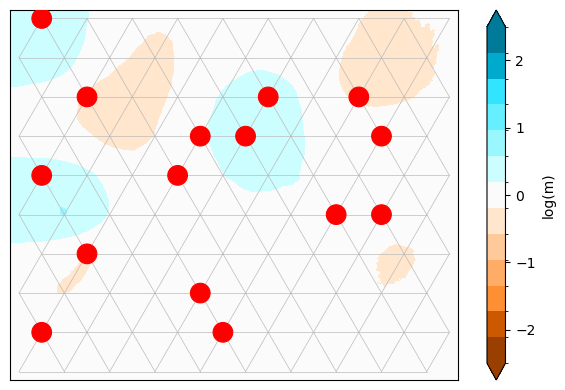

In [5]:

# =====================================================
# 7. MAIN PIPELINE
# =====================================================

# --- 7.1 EEMS surfaces (m and q) ---
dimns_m, z_m, pr_gt0_m, pr_lt0_m = compute_eems_surface_multi(
    CHAIN_DIRS, longlat=LONG_LAT, nmrks=NMRKS, is_mrates=True
)
# dimns_q, z_q, pr_gt0_q, pr_lt0_q = compute_eems_surface_multi(
#     CHAIN_DIRS, longlat=LONG_LAT, nmrks=NMRKS, is_mrates=False
# )

print("\nEEMS surfaces computed (m and q).")

# Optional: quick plots
fig_m, ax_m = plot_eems_rate_map(dimns_m, z_m, is_mrates=True,
                                 add_grid=True, add_demes=True, add_outline=False)
# fig_q, ax_q = plot_eems_rate_map(dimns_q, z_q, is_mrates=False,
#                                  add_grid=True, add_demes=True, add_outline=False)

# --- 7.2 Build migration regions + skeletons ---
regions_m = build_signed_region_masks_and_polygons(dimns_m, z_m, thresh=0.0)
pos_region_m = regions_m["pos_region"]
neg_region_m = regions_m["neg_region"]

# Save pos/neg migration regions
crs_ll = "EPSG:4326" if LONG_LAT else None
if pos_region_m is not None and not pos_region_m.is_empty:
    gpd.GeoDataFrame(
        {"type": ["pos_migration"]},
        geometry=[pos_region_m],
        crs=crs_ll,
    ).to_file(
        OUT_GEOJSON_DIR / f"{RUN_NAME}_pos_migration_region.geojson",
        driver="GeoJSON",
    )
if neg_region_m is not None and not neg_region_m.is_empty:
    gpd.GeoDataFrame(
        {"type": ["neg_migration"]},
        geometry=[neg_region_m],
        crs=crs_ll,
    ).to_file(
        OUT_GEOJSON_DIR / f"{RUN_NAME}_neg_migration_region.geojson",
        driver="GeoJSON",
    )

# Skeletons from masks
pos_skel_mask = skeletonize(regions_m["pos_mask"].astype(bool))
neg_skel_mask = skeletonize(regions_m["neg_mask"].astype(bool))

pos_skel_all = skeleton_mask_to_lines(
    pos_skel_mask, dimns_m["xlim"], dimns_m["ylim"], crs=crs_ll
)
neg_skel_all = skeleton_mask_to_lines(
    neg_skel_mask, dimns_m["xlim"], dimns_m["ylim"], crs=crs_ll
)

# Save all skeletons
pos_skel_all.to_file(
    OUT_GEOJSON_DIR / f"{RUN_NAME}_pos_migration_skeleton_all.geojson",
    driver="GeoJSON",
)
neg_skel_all.to_file(
    OUT_GEOJSON_DIR / f"{RUN_NAME}_neg_migration_skeleton_all.geojson",
    driver="GeoJSON",
)

# --- 7.3 Skeleton selection by nearest sample distance ---
demes = np.asarray(dimns_m["demes"], dtype=float)
mask_samples = demes[:, 2] > 0
sample_xy = demes[mask_samples, :2]

print("# sampled demes:", sample_xy.shape[0])

D_med_neg, d_min_neg = compute_Dmed_from_skeletons(neg_skel_all, sample_xy)
neg_skel_all["d_min"] = d_min_neg
mask_sel_neg = np.isfinite(d_min_neg) & (d_min_neg <= D_med_neg)
neg_skel_sel = neg_skel_all.loc[mask_sel_neg].copy()
print("Selected NEG skeleton segments:", len(neg_skel_sel))

neg_skel_sel.to_file(
    OUT_GEOJSON_DIR / f"{RUN_NAME}_neg_migration_skeleton_selected.geojson",
    driver="GeoJSON",
)

# --- 7.4 KDE from sample locations + Jenks 4-class ---
kde_res = kernel_density_quartic(
    sample_xy=sample_xy,
    weights=None,
    xlim=dimns_m["xlim"],
    ylim=dimns_m["ylim"],
    cell_factor=KDE_CELL_FACTOR,
    bandwidth=None,
)
kd_class, kd_breaks = classify_jenks_4(kde_res["density"])
# --- 7.5 Split NEG skeleton by KDE class ---
neg_seg = segment_skeletons_by_kde_class(
    neg_skel_sel,
    kd_class,
    kde_res,
    min_points_per_segment=3,
    samples_per_cell=4,
    min_class_keep=1,
)

# --- 7.6 Posterior P(log(m)<0) ≥ PROB_LEVEL region ---
neg_prob_gdf, neg_prob_grid, (ny_prob, nx_prob) = build_prob_region_from_vector(
    dimns_m,
    pr_lt0_m,
    prob_thresh=PROB_LEVEL,
    label="P(log(m)<0)",
)
neg_prob_geom = neg_prob_gdf.geometry.iloc[0]

# ------------------------------------------------------
# Helper: compute confusion metrics from an edges_gdf
# ------------------------------------------------------
def confusion_from_edges(edges_gdf, pred_col="pred_barrier"):
    """
    Compute TP, FN, FP, TN, Accuracy, Recall, Precision
    from an edges GeoDataFrame with columns:
      - is_barrier (0/1)
      - pred_col   (0/1, e.g. 'pred_barrier')
    """
    metrics = {
        "TP": np.nan,
        "FN": np.nan,
        "FP": np.nan,
        "TN": np.nan,
        "Accuracy": np.nan,
        "Recall": np.nan,
        "Precision": np.nan,
    }

    if pred_col not in edges_gdf.columns:
        print(f"[warning] Column '{pred_col}' not found in edges_gdf; metrics set to NaN.")
        return metrics

    gt = edges_gdf["is_barrier"].astype(int).values
    pred = edges_gdf[pred_col].astype(int).values
    N = len(gt)
    if N == 0:
        print("[warning] edges_gdf is empty; metrics set to NaN.")
        return metrics

    TP = int(((gt == 1) & (pred == 1)).sum())
    TN = int(((gt == 0) & (pred == 0)).sum())
    FP = int(((gt == 0) & (pred == 1)).sum())
    FN = int(((gt == 1) & (pred == 0)).sum())

    acc = (TP + TN) / N if N else np.nan
    recall = TP / (TP + FN) if (TP + FN) else np.nan
    precision = TP / (TP + FP) if (TP + FP) else np.nan

    metrics.update(
        {
            "TP": TP,
            "FN": FN,
            "FP": FP,
            "TN": TN,
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
        }
    )
    return metrics


# ------------------------------------------------------
# 7.7 Multi-scale SLA: 0.5, 1.0, 2.0
#   * build SLA for each scale
#   * intersect with posterior region
#   * validate vs ground truth
#   * write one CSV with 3 columns (one per scale)
# ------------------------------------------------------
sla_multiscale_metrics = {}
edges_for_plot = None  # keep the scale=1.0 edges for plotting if desired
sla_region_for_plot = None   # <--- add this

prob_suffix = f"{int(PROB_LEVEL * 100):02d}"

for sf in SLA_SCALE_FACTORS:
    scale_tag = f"{sf:.1f}".replace(".", "p")  # 0.5 -> "0p5", etc.
    print(f"\n=== Building SLA for scale factor {sf} (tag={scale_tag}) ===")

    # 7.7.1 Build SLA buffers for this scale
    neg_sla_sf = build_sla_buffers(
        neg_seg,
        D_med_neg,
        region_clip=neg_region_m,
        scale_factor=sf,
    )

    # Save SLA polygons for this scale
    sla_path = OUT_GEOJSON_DIR / f"{RUN_NAME}_neg_migration_SLA_scale{scale_tag}.geojson"
    neg_sla_sf.to_file(sla_path, driver="GeoJSON")
    print(f"SLA polygons (scale={sf}) saved to: {sla_path}")

    # Merge SLA polygons to a single geometry
    if len(neg_sla_sf) == 0:
        print(f"[warning] No SLA polygons for scale={sf}; using empty geometry.")
        sla_geom_sf = Polygon()
    else:
        sla_geom_sf = unary_union(neg_sla_sf.geometry)

    neg_sla_merged_sf = gpd.GeoDataFrame(
        {"id": [1], "scale": [sf]}, geometry=[sla_geom_sf], crs=neg_sla_sf.crs
    )
    sla_merged_path = (
        OUT_GEOJSON_DIR
        / f"{RUN_NAME}_neg_migration_SLA_scale{scale_tag}_merged.geojson"
    )
    neg_sla_merged_sf.to_file(sla_merged_path, driver="GeoJSON")
    print(f"Merged SLA (scale={sf}) saved to: {sla_merged_path}")
    print("Merged SLA geom type:", sla_geom_sf.geom_type)

    # 7.7.2 Intersection with posterior region P(log(m)<0) ≥ PROB_LEVEL
    intersection_geom_sf = sla_geom_sf.intersection(neg_prob_geom)
    sla_neg_prob_sf = gpd.GeoDataFrame(
        {"id": [1], "scale": [sf], "prob_min": [PROB_LEVEL]},
        geometry=[intersection_geom_sf],
        crs=neg_sla_sf.crs,
    )

    sla_neg_prob_path_sf = (
        OUT_GEOJSON_DIR
        / f"{RUN_NAME}_neg_migration_SLA_scale{scale_tag}_prob{prob_suffix}_intersection.geojson"
    )
    sla_neg_prob_sf.to_file(sla_neg_prob_path_sf, driver="GeoJSON")
    print(
        f"SLA ∩ P(log(m)<0≥{PROB_LEVEL}) (scale={sf}) saved to: {sla_neg_prob_path_sf}"
    )
    print("Intersection geometry type:", intersection_geom_sf.geom_type)

    # 7.7.3 Validation vs. ground truth for this scale
    region_sla_sf = unary_union(sla_neg_prob_sf.geometry)
    # region_sla_sf = sla_neg_prob_sf.geometry.unary_union
    edges_gdf_sf = validate_barriers_with_region(
        region_sla_sf,
        POPCOORDS_FILE,
        EDGERATES_FILE,
        barrier_rate=BARRIER_RATE,
        frac_threshold=EDGE_FRAC_THRESHOLD,
        label=f"SLA ∩ posterior (scale={sf})",
    )

    # Save confusion metrics for this scale
    metrics_sf = confusion_from_edges(edges_gdf_sf, pred_col="pred_barrier")
    sla_multiscale_metrics[f"scale_{sf:.1f}"] = metrics_sf

    # keep the scale=1.0 edges for plotting (if you use plot_overlap_vs_edges later)
    if abs(sf - 1.0) < 1e-8:
        edges_for_plot = edges_gdf_sf.copy()

# 7.7.4 Write multiscale CSV (3 columns: 0.5, 1.0, 2.0)
metrics_index = ["TP", "FN", "FP", "TN", "Accuracy", "Recall", "Precision"]
metrics_df = pd.DataFrame(
    {
        col_name: {k: sla_multiscale_metrics[col_name][k] for k in metrics_index}
        for col_name in sla_multiscale_metrics.keys()
    },
    index=metrics_index,
)

csv_path = OUT_GEOJSON_DIR / f"{RUN_NAME}_neg_SLA_multiscale_confusion.csv"
metrics_df.to_csv(csv_path, index_label="metric")
print(f"\nMultiscale SLA confusion metrics written to: {csv_path}")

# 7.7.5 (Optional) validate posterior-only region once (no CSV column)
region_post   = unary_union(neg_prob_gdf.geometry)

#region_post = neg_prob_gdf.geometry.unary_union
_ = validate_barriers_with_region(
    region_post,
    POPCOORDS_FILE,
    EDGERATES_FILE,
    barrier_rate=BARRIER_RATE,
    frac_threshold=EDGE_FRAC_THRESHOLD,
    label="posterior-only region",
)

print("\nPipeline finished.")

# 7.7.5 Optional: overlap plot for scale = 1.0
if edges_for_plot is not None and sla_region_for_plot is not None:
    fig_overlap, ax_overlap = plot_overlap_vs_edges(
        sla_region=sla_region_for_plot,   # shapely geometry
        edges_gdf=edges_for_plot,         # GeoDataFrame with pred_barrier
        title=f"{RUN_NAME}: NEG SLA ∩ P[log(m)<0≥{PROB_LEVEL}] vs ground-truth edges (scale=1.0)",
    )


# Use the edges with predictions from the SLA validation
# edges_gdf_sla = res_sla["edges"]
# sla_region    = region_sla

# fig_overlap, ax_overlap = plot_overlap_vs_edges(
#     sla_region=sla_neg_prob_sf.geometry.unary_union,  # or region for chosen scale
#     edges_gdf=edges_for_plot,
#     title=f"{RUN_NAME}: NEG SLA ∩ P[log(m)<0≥{PROB_LEVEL}] vs ground-truth edges",
# )
# overlap_path = FIG_DIR / f"{RUN_NAME}_neg_SLA_prob{int(PROB_LEVEL*100):02d}_overlap_vs_edges.png"
# _save_fig(fig_overlap, overlap_path)


In [6]:
# 1) get sample points
sample_points_m = get_sample_points(dimns_m)
print(f"Number of sampled demes (migration): {len(sample_points_m)}")
# Example: compute skeletons for positive (blue) and negative (orange) regions
pos_mig_region, neg_mig_region = build_pos_neg_polygons(dimns_m, z_m)
pos_mig_skel = polygon_to_skeleton_lines(pos_mig_region, nx=400)
neg_mig_skel = polygon_to_skeleton_lines(neg_mig_region, nx=400)
D_pos, D_pos_med, pos_skel_selected, pos_skel_removed = \
    select_skeletons_by_distance(pos_mig_skel, sample_points_m)
D_neg, D_neg_med, neg_skel_selected, neg_skel_removed = \
    select_skeletons_by_distance(neg_mig_skel, sample_points_m)

print(f"[pos] #segments = {len(D_pos)}, D_med = {D_pos_med:.6f}")
print(f"[neg] #segments = {len(D_neg)}, D_med = {D_neg_med:.6f}")

# =======================================
# FIGURE GENERATION + PNG EXPORT SECTION
# =======================================
from pathlib import Path
import matplotlib.pyplot as plt

# Directory for this run's figures
FIG_DIR = BASE_DIR / "eems_figs" / RUN_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Toggle: whether to SHOW figures in notebook while saving
SHOW_FIGURES = True   # set to False if you only want PNGs, no display


# SLA overlap from this run
SLA_OVERLAP_FILE = OUT_GEOJSON_DIR / f"{RUN_NAME}_neg_migration_SLA_prob90_intersection.geojson"

sla_neg_prob = gpd.read_file(SLA_OVERLAP_FILE)
sla_region = sla_neg_prob.geometry.unary_union
print("Loaded overlap (NEG SLA ∩ P[log(m)<0]≥0.9) from:", SLA_OVERLAP_FILE)
print("Overlap geometry type:", sla_region.geom_type)



Number of sampled demes (migration): 15
[pos] #segments = 983, D_med = 0.104506
[neg] #segments = 976, D_med = 0.117546
Loaded overlap (NEG SLA ∩ P[log(m)<0]≥0.9) from: /Users/yli129/Library/Mobile Documents/com~apple~CloudDocs/eems_new_sim/master_script/output/all_flat_sim5/all_flat_sim5/eems_geojson/sim5_N15_rep009/sim5_N15_rep009_neg_migration_SLA_prob90_intersection.geojson
Overlap geometry type: GeometryCollection


/var/folders/nh/fsq5yn9n2nl38rzgt_3b8rwh0000gp/T/ipykernel_29485/389744768.py:34: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  sla_region = sla_neg_prob.geometry.unary_union


Number of demes: 100
      x    y
id          
0   0.0  0.0
1   0.1  0.0
2   0.2  0.0
3   0.3  0.0
4   0.4  0.0
Number of edges in ground truth: 261
   deme_i  deme_j   rate
0       0       1  0.020
1       0      10  0.001
2       1       2  0.001
3       1      10  0.020
4       1      11  0.020
Rate counts:
 rate
0.020    165
0.001     96
Name: count, dtype: int64
   deme_i  deme_j   rate  is_barrier                         geometry
0       0       1  0.020           0          LINESTRING (0 0, 0.1 0)
1       0      10  0.001           1    LINESTRING (0 0, 0.05 0.0866)
2       1       2  0.001           1        LINESTRING (0.1 0, 0.2 0)
3       1      10  0.020           0  LINESTRING (0.1 0, 0.05 0.0866)
4       1      11  0.020           0  LINESTRING (0.1 0, 0.15 0.0866)
Saving figures to: /Users/yli129/Library/Mobile Documents/com~apple~CloudDocs/eems_new_sim/master_script/output/all_flat_sim5/all_flat_sim5/eems_figs/sim5_N15_rep009
Jenks breaks: [np.float64(1.6632582897208462

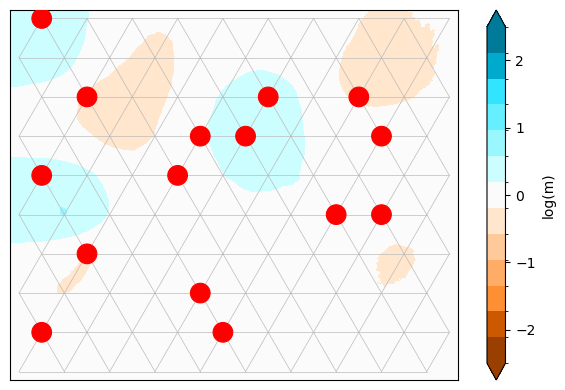

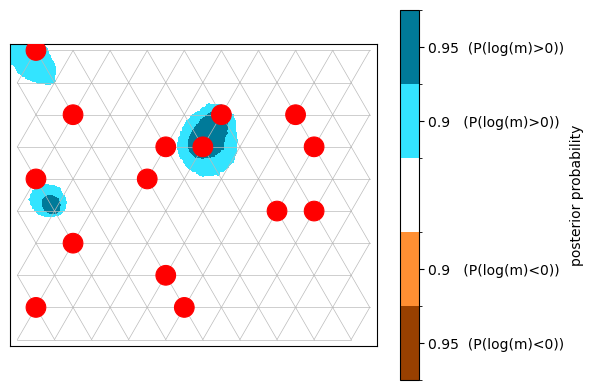

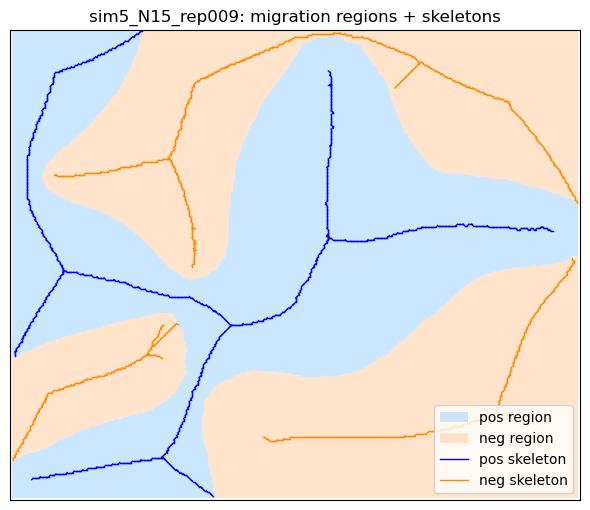

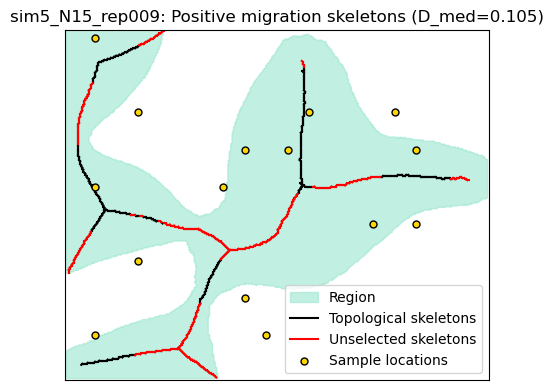

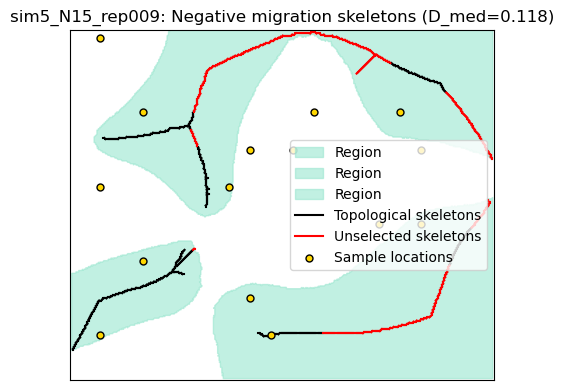

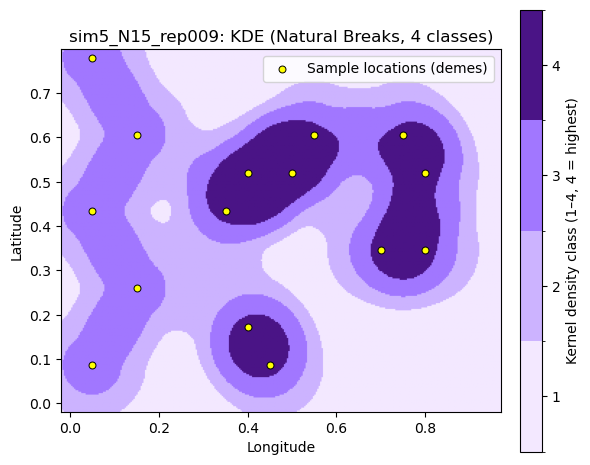

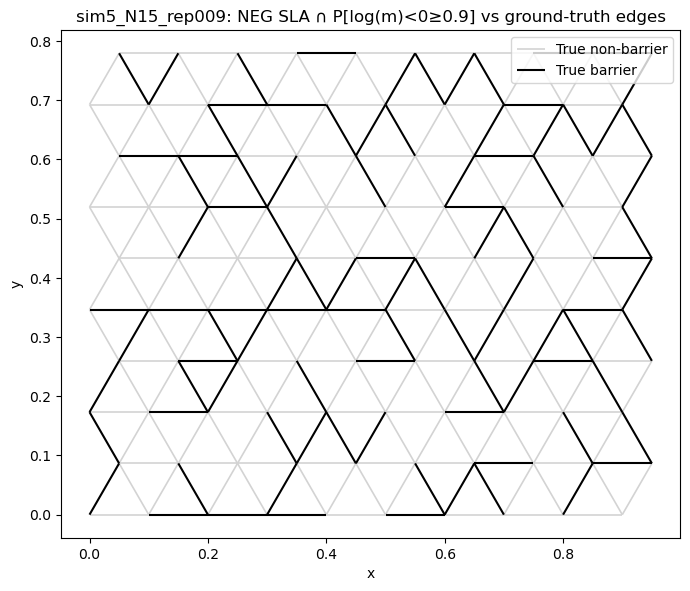

In [7]:

# ----------------------------------------------------
# 2. READ DEME LOCATIONS (sim5.popcoords)
#    format:  id  x  y
# ----------------------------------------------------
pop = pd.read_csv(POPCOORDS_FILE, sep=r"\s+", header=None, names=["id", "x", "y"])
pop = pop.set_index("id")
print("Number of demes:", len(pop))
print(pop.head())

# Helper: get XY for a deme id
def deme_xy(deme_id):
    row = pop.loc[int(deme_id)]
    return float(row["x"]), float(row["y"])

# ----------------------------------------------------
# 3. READ EDGE RATES (sim5.edgerates)
#    format:  deme_i  deme_j  rate
# ----------------------------------------------------
edges_df = pd.read_csv(EDGERATES_FILE, sep=r"\s+", header=None,
                       names=["deme_i", "deme_j", "rate"])
print("Number of edges in ground truth:", len(edges_df))
print(edges_df.head())
print("Rate counts:\n", edges_df["rate"].value_counts())

# 0.001 edges = "barrier" edges (thin edges in your ground-truth figure)
BARRIER_RATE = 0.001

# ----------------------------------------------------
# 4. BUILD EDGE GEOMETRIES
# ----------------------------------------------------
geoms = []
is_barrier = []

for row in edges_df.itertuples(index=False):
    x1, y1 = deme_xy(row.deme_i)
    x2, y2 = deme_xy(row.deme_j)
    geoms.append(LineString([(x1, y1), (x2, y2)]))
    is_barrier.append(1 if abs(row.rate - BARRIER_RATE) < 1e-10 else 0)

edges_gdf = gpd.GeoDataFrame(
    {
        "deme_i": edges_df["deme_i"],
        "deme_j": edges_df["deme_j"],
        "rate":   edges_df["rate"],
        "is_barrier": is_barrier,
    },
    geometry=geoms,
    crs=sla_neg_prob.crs,   # same numeric coordinate system as SLA region
)

print(edges_gdf.head())



def _save_fig(fig, path: Path, show: bool = SHOW_FIGURES, dpi: int = 300):
    """Save figure to PNG and optionally close instead of showing."""
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    if not show:
        plt.close(fig)

print(f"Saving figures to: {FIG_DIR}")

# 1) EEMS migration rate (log m) map
fig_mrate, ax_mrate = plot_eems_rate_map(
    dimns_m,
    z_m,
    is_mrates=True,
    add_grid=ADD_GRID,
    add_demes=ADD_DEMES,
    add_outline=ADD_OUTLINE,
)
mrate_path = FIG_DIR / f"{RUN_NAME}_mrates01_rate_map.png"
_save_fig(fig_mrate, mrate_path)

# 2) EEMS posterior probability map (migration)
fig_mprob, ax_mprob = plot_eems_prob_map(
    dimns_m,
    pr_gt0_m,
    pr_lt0_m,
    is_mrates=True,
    prob_low=0.9,
    prob_high=0.95,
    add_grid=ADD_GRID,
    add_demes=ADD_DEMES,
    add_outline=ADD_OUTLINE,
)
mprob_path = FIG_DIR / f"{RUN_NAME}_mrates02_prob_map.png"
_save_fig(fig_mprob, mprob_path)

# 3) Positive/negative regions + skeletons overview
fig_regions, ax_regions = plot_pos_neg_regions_and_skeletons(
    dimns_m,
    pos_mig_region,
    neg_mig_region,
    pos_mig_skel,
    neg_mig_skel,
    title=f"{RUN_NAME}: migration regions + skeletons",
)
regions_path = FIG_DIR / f"{RUN_NAME}_regions_skeletons.png"
_save_fig(fig_regions, regions_path)

# 4) Skeleton selection – positive migration
fig_pos_sel, ax_pos_sel = plot_region_skeleton_selection(
    pos_mig_region,
    pos_skel_selected,
    pos_skel_removed,
    sample_points_m,
    dimns_m,
    title=f"{RUN_NAME}: Positive migration skeletons (D_med={D_pos_med:.3g})",
)
pos_sel_path = FIG_DIR / f"{RUN_NAME}_pos_skeleton_selection.png"
_save_fig(fig_pos_sel, pos_sel_path)

# 5) Skeleton selection – negative migration
fig_neg_sel, ax_neg_sel = plot_region_skeleton_selection(
    neg_mig_region,
    neg_skel_selected,
    neg_skel_removed,
    sample_points_m,
    dimns_m,
    title=f"{RUN_NAME}: Negative migration skeletons (D_med={D_neg_med:.3g})",
)
neg_sel_path = FIG_DIR / f"{RUN_NAME}_neg_skeleton_selection.png"
_save_fig(fig_neg_sel, neg_sel_path)

# 6) KDE 4-class purple map + sampled demes
fig_kde, ax_kde = plot_kde_classes(
    kde_res,
    sample_xy,
    title=f"{RUN_NAME}: KDE (Natural Breaks, 4 classes)",
)
kde_path = FIG_DIR / f"{RUN_NAME}_kde_classes.png"
_save_fig(fig_kde, kde_path)

# 7) NEG SLA ∩ posterior >= 0.9 vs ground-truth edges
fig_overlap, ax_overlap = plot_overlap_vs_edges(
    sla_region,
    edges_gdf,
    title=f"{RUN_NAME}: NEG SLA ∩ P[log(m)<0≥0.9] vs ground-truth edges",
)
overlap_path = FIG_DIR / f"{RUN_NAME}_neg_SLA_prob09_overlap_vs_edges.png"
_save_fig(fig_overlap, overlap_path)

print("Figure export completed. Saved PNGs:")
for p in [
    mrate_path,
    mprob_path,
    regions_path,
    pos_sel_path,
    neg_sel_path,
    kde_path,
    overlap_path,
]:
    print("  -", p)